In [ ]:
import netCDF4 as nc
import numpy as np
import torch

def sww_to_depth_tensor_gpu(sww_file, nx=150, ny=150, min_depth_threshold=0.01, device='cuda'):
    """
    Interpolates SWW data to a uniform grid of size (nx, ny) and extracts elevation.
    Target resolution is inferred from the bounding box and the specified nx/ny.
    """

    # 1. Load data
    ds = nc.Dataset(sww_file, 'r')
    x_raw = ds.variables['x'][:]
    y_raw = ds.variables['y'][:]
    elevation_raw = ds.variables['elevation'][:]  
    stage_all_raw = ds.variables['stage'][:]
    ds.close()

    # 2. Calculate Depth (NumPy)
    depth_all_raw = stage_all_raw - elevation_raw
    depth_all_raw = np.nan_to_num(depth_all_raw, nan=0.0)
    depth_all_raw[depth_all_raw < min_depth_threshold] = 0.0
    nt, num_nodes = depth_all_raw.shape

    # 3. Transfer to GPU
    points_gpu = torch.stack([
        torch.from_numpy(x_raw).to(device).float(),
        torch.from_numpy(y_raw).to(device).float()
    ], dim=1)
    
    depth_gpu = torch.from_numpy(depth_all_raw).to(device).float()
    elev_gpu = torch.from_numpy(elevation_raw).to(device).float()

    # 4. Create Uniform Target Grid based on nx and ny
    x_min, x_max = x_raw.min(), x_raw.max()
    y_min, y_max = y_raw.min(), y_raw.max()

    # Using steps=nx and steps=ny to create the linspace directly
    lin_x = torch.linspace(x_min, x_max, steps=nx, device=device)
    lin_y = torch.linspace(y_min, y_max, steps=ny, device=device)
    
    # Generate grid coordinates
    mesh_y, mesh_x = torch.meshgrid(lin_y, lin_x, indexing='ij')
    grid_coords = torch.stack([mesh_x.flatten(), mesh_y.flatten()], dim=1)

    # 5. Find Nearest Neighbors (Chunked)
    num_grid_points = nx * ny
    nearest_indices = torch.zeros(num_grid_points, dtype=torch.long, device=device)
    
    chunk_size = 5000 
    for i in range(0, num_grid_points, chunk_size):
        end_i = min(i + chunk_size, num_grid_points)
        dists = torch.cdist(grid_coords[i:end_i], points_gpu) 
        nearest_indices[i:end_i] = torch.argmin(dists, dim=1)
        
    # 6. Map Depth (all timesteps) and Elevation (static)
    depth_interp_flat = depth_gpu[:, nearest_indices]
    elev_interp_flat = elev_gpu[nearest_indices]
    
    # 7. Reshape and Permute to maintain original [nx, ny, nt] and [nx, ny] output
    tensor_depth = depth_interp_flat.view(nt, ny, nx).permute(2, 1, 0)
    tensor_elev = elev_interp_flat.view(ny, nx).T
    
    grid_x_2d = mesh_x.T # [nx, ny]
    grid_y_2d = mesh_y.T # [nx, ny]
    
    return tensor_depth, tensor_elev, grid_x_2d, grid_y_2d

In [ ]:
import torch
import netCDF4 as nc
import numpy as np
import os

def generate_gaussian_discharge_tensor(tms_dir, grid_x_2d, grid_y_2d, radius=500.0, time_factor=6, device='cuda'):
    """
    Creates a unified spatio-temporal tensor for discharge (Q) using 2D Gaussian kernels
    and Temporal Block Summation with padding to ensure specific output dimensions.
    
    Inputs:
    -------
    - tms_dir (str): Directory containing gauge .tms files.
    - grid_x_2d/grid_y_2d (torch.Tensor): 2D coordinate matrices [nx, ny].
    - gauges (list): Metadata for gauge locations and IDs.
    - radius (float): Spatial influence cutoff.
    - time_factor (int): Factor to reduce the time dimension (e.g., 6).
    - device (str): Target device ('cuda' or 'cpu').

    Outputs:
    --------
    - q_tensor (torch.Tensor): Shape [nx, ny, ceil(nt / time_factor)].
    - aggregated_time (np.array): Reduced timeline.
    """
    
    gauges = [
        {"id": "Bc1_8791413",  "x": 203142.27, "y": 3922226.29},
        {"id": "Bc2_8790751",  "x": 209767.46, "y": 3915832.46},
        {"id": "Bc3_8790719",  "x": 214258.80, "y": 3920627.66},
        {"id": "Bc4_8790801",  "x": 215750.40, "y": 3914499.44},
        {"id": "Bc5_8790519",  "x": 218575.49, "y": 3920699.28},
        {"id": "Bc6_8790559",  "x": 225078.15, "y": 3921002.98},
        {"id": "Bc7_11235707", "x": 227582.00, "y": 3915030.09},
        {"id": "Bc8_11236643", "x": 231177.77, "y": 3904981.34},
    ]


    nx, ny = grid_x_2d.shape
    x_offset = 201527.93407489875
    y_offset = 3898940.192838932
    sigma = radius / 2.0 

    # 1. TEMPORAL SYNCHRONIZATION
    master_time = None
    for gauge in gauges:
        usgs_id = gauge['id'].split('_')[-1]
        tms_path = os.path.join(tms_dir, f"{usgs_id}.tms")
        if os.path.exists(tms_path):
            with nc.Dataset(tms_path, 'r') as ds:
                master_time = ds.variables['time'][:].copy()
            break 
            
    if master_time is None:
        raise FileNotFoundError("Could not find any .tms files.")
    
    nt_orig = len(master_time)
    
    # 2. PADDING LOGIC (To reach 45 steps from 265)
    # Calculate how many extra steps are needed to be divisible by time_factor
    remainder = nt_orig % time_factor
    padding_size = (time_factor - remainder) if remainder > 0 else 0
    nt_padded = nt_orig + padding_size
    nt_new = nt_padded // time_factor # This will be 45 for nt_orig=265, factor=6

    # 3. TENSOR ALLOCATION (Allocate with padded size)
    q_tensor = torch.zeros((nx, ny, nt_padded), device=device)

    # 4. KERNEL GENERATION AND DATA INJECTION
    for gauge in gauges:
        usgs_id = gauge['id'].split('_')[-1]
        tms_path = os.path.join(tms_dir, f"{usgs_id}.tms")
        
        if not os.path.exists(tms_path):
            continue

        with nc.Dataset(tms_path, 'r') as ds:
            q_values = ds.variables['discharge'][:]
        
        q_gpu = torch.from_numpy(q_values).to(device).float()
        local_gx = gauge['x'] - x_offset
        local_gy = gauge['y'] - y_offset

        # 5. SPATIAL WEIGHTING
        dist_sq = (grid_x_2d - local_gx)**2 + (grid_y_2d - local_gy)**2
        weights = torch.exp(-dist_sq / (2 * sigma**2))
        weights[dist_sq > radius**2] = 0 
        
        if weights.sum() > 0:
            weights = weights / weights.sum()

        # 6. INJECTION (Inject original values into the start of the padded tensor)
        # The remaining steps (266-270) remain zero-filled
        q_tensor[..., :nt_orig] += weights.unsqueeze(-1) * q_gpu.unsqueeze(0).unsqueeze(0)

    # 7. TEMPORAL BLOCK SUMMATION
    # Reshape and sum along the block dimension
    q_tensor = q_tensor.view(nx, ny, nt_new, time_factor).sum(dim=-1)

    # 8. TIME AGGREGATION
    # Pad master_time with the last timestamp to match length before reshaping
    if padding_size > 0:
        last_time = master_time[-1]
        time_padding = np.full(padding_size, last_time)
        master_time_padded = np.concatenate([master_time, time_padding])
    else:
        master_time_padded = master_time

    aggregated_time = master_time_padded.reshape(nt_new, time_factor).mean(axis=-1)

    return q_tensor, aggregated_time

In [ ]:
import os
import torch
import re
import numpy as np
from tqdm import tqdm

def process_root_to_depth_tensors(root_dir, nx=328, ny=164, threshold=0.025, q_radius=500.0, time_factor=6):
    """
    Processes scenarios by pre-allocating CPU memory to prevent 'cat' memory spikes.
    Static data (grid, elevation, time) is stored only once.
    """
    # 1. First Pass: Find all valid scenarios to determine 'nbatch'
    sww_pattern = re.compile(r"Hurricane_group_.*_scenario_.*_merged\.sww$")
    scenario_list = []
    
    for root, dirs, files in os.walk(root_dir):
        for file in files:
            if sww_pattern.match(file):
                tms_dir = os.path.join(root, 'tms_files')
                if os.path.exists(tms_dir):
                    scenario_list.append((os.path.join(root, file), tms_dir))
    
    nbatch = len(scenario_list)
    if nbatch == 0:
        return None

    # 2. Get dimensions from the first scenario to pre-allocate
    first_sww, first_tms = scenario_list[0]
    d_sample, e_sample, gx_sample, gy_sample = sww_to_depth_tensor_gpu(first_sww, nx=nx, ny=ny, min_depth_threshold=threshold)
    q_sample, t_sample = generate_gaussian_discharge_tensor(first_tms, gx_sample, gy_sample, radius=q_radius, time_factor=time_factor)
    
    nx, ny, nt = d_sample.shape
    
    # 3. Pre-allocate dynamic tensors on CPU
    # This allocates the memory ONCE. No more growing lists or 'cat' operations.
    batch_depth = torch.zeros((nbatch, nx, ny, nt), dtype=torch.float32)
    # batch_q = torch.zeros((nbatch, nx, ny, nt), dtype=torch.float32)
    
    # Store static data only once
    final_elevation = e_sample.cpu()
    final_gx = gx_sample.cpu()
    final_gy = gy_sample.cpu()
    final_time = torch.from_numpy(t_sample).float()

    print(f"Pre-allocated CPU memory for {nbatch} scenarios ({nx}x{ny}x{nt})")

    # 4. Second Pass: Fill the pre-allocated tensors

    for i, (sww_path, tms_dir) in enumerate(tqdm(scenario_list, desc="Processing Scenarios")):
        try:
            # Process on GPU for speed
            depth, _, gx, gy = sww_to_depth_tensor_gpu(sww_path, nx=nx, ny=ny, min_depth_threshold=threshold)
            # q_tensor, _ = generate_gaussian_discharge_tensor(tms_dir, gx, gy, radius=q_radius, time_factor=time_factor)
            
            # Direct assignment to the CPU tensor
            batch_depth[i] = depth.cpu()
            # batch_q[i] = q_tensor.cpu()
            
            # Explicitly clean up GPU memory after each scenario
            del (depth, 
                # q_tensor, 
                gx, 
                gy)
            torch.cuda.empty_cache()
            
            # Note: You can remove the old "if (i+1) % 5" print statements 
            # as tqdm provides a much cleaner live update.
                
        except Exception as e:
            # Using tqdm.write prevents the error message from breaking the progress bar
            tqdm.write(f"Error processing scenario {i}: {e}")

    return {
        "depth": batch_depth,      # [nbatch, nx, ny, nt]
        # "discharge": batch_q,      # [nbatch, nx, ny, nt]
        "elevation": final_elevation, 
        # "grid_x": final_gx, 
        # "grid_y": final_gy,
        # "time": final_time
    }

In [ ]:
import os
import torch
import re
import numpy as np
from tqdm import tqdm

def process_root_to_q_tensors(root_dir, nx=328, ny=164, q_radius=500.0, time_factor=6):
    """
    Processes scenarios by pre-allocating CPU memory for discharge (Q) only.
    Returns the batched Q tensor and the synchronized time array.
    """
    # 1. First Pass: Find all valid scenarios that have a 'tms_files' directory
    sww_pattern = re.compile(r"Hurricane_group_.*_scenario_.*_merged\.sww$")
    scenario_list = []
    
    for root, dirs, files in os.walk(root_dir):
        for file in files:
            if sww_pattern.match(file):
                tms_dir = os.path.join(root, 'tms_files')
                if os.path.exists(tms_dir):
                    scenario_list.append((os.path.join(root, file), tms_dir))
    
    nbatch = len(scenario_list)
    if nbatch == 0:
        print("No scenarios with 'tms_files' found.")
        return None

    # 2. Get spatial and temporal dimensions from the first scenario
    # We still need one call to sww_to_depth_tensor to get the grid (gx, gy)
    first_sww, first_tms = scenario_list[0]
    _, _, gx_sample, gy_sample = sww_to_depth_tensor_gpu(first_sww, nx=nx, ny=ny)
    
    # Generate a sample Q to determine the final 'nt' after time_factor aggregation
    q_sample, t_sample = generate_gaussian_discharge_tensor(
        first_tms, gx_sample, gy_sample, radius=q_radius, time_factor=time_factor
    )
    
    nx, ny, nt = q_sample.shape
    
    # 3. Pre-allocate dynamic Discharge tensor on CPU RAM
    batch_q = torch.zeros((nbatch, nx, ny, nt), dtype=torch.float32)
    
    # Store the synchronized time only once
    final_time = torch.from_numpy(t_sample).float()

    print(f"Pre-allocated CPU memory for {nbatch} Discharge scenarios ({nx}x{ny}x{nt})")

    # 4. Second Pass: Fill the pre-allocated Discharge tensor
    for i, (sww_path, tms_dir) in enumerate(tqdm(scenario_list, desc="Generating Q Tensors")):
        try:
            # We need the grid for each scenario to ensure spatial alignment
            _, _, gx, gy = sww_to_depth_tensor_gpu(sww_path, nx=nx, ny=ny)
            
            # Generate Gaussian Q
            q_tensor, _ = generate_gaussian_discharge_tensor(
                tms_dir, gx, gy, radius=q_radius, time_factor=time_factor
            )
            
            # Direct assignment to CPU memory
            batch_q[i] = q_tensor.cpu()
            
            # Explicitly clean up GPU memory
            del q_tensor, gx, gy
            torch.cuda.empty_cache()
                
        except Exception as e:
            tqdm.write(f"Error processing scenario {i}: {e}")

    return {
        "discharge": batch_q, # [nbatch, nx, ny, nt]
        "time": final_time     # [nt]
    }

In [ ]:
from pathlib import Path

MAIN_PATH = '/storage/group/cxs1024/default/mehdi/Hurricane_Matthew_scenario_groups/scenario_groups_1/'

# Create the directory
# parents=True: creates missing parent folders
# exist_ok=True: doesn't throw an error if the folder already exists
Path(MAIN_PATH).mkdir(parents=True, exist_ok=True)

print(f"Path verified: {MAIN_PATH}")

In [ ]:
import os
import torch

# ==========================================
# 1. Process and Save Target Tensors (Depth & Elevation)
# ==========================================
# Generate depth and static terrain data
DATA_depth = process_root_to_depth_tensors(MAIN_PATH, q_radius=1000)

# Define file paths for the solution (Target) and bed (Static) tensors
solution_file = os.path.join(MAIN_PATH, "hurricane_matthew_processed_data_solution_2.pt")
bed_file      = os.path.join(MAIN_PATH, "hurricane_matthew_processed_data_bed_2.pt")

print(f"Saving Target tensors to: {MAIN_PATH}")
torch.save(DATA_depth['depth'], solution_file)
torch.save(DATA_depth['elevation'], bed_file)

# Explicitly clear memory before starting the next heavy process
del DATA_depth
torch.cuda.empty_cache()

# ==========================================
# 2. Process and Save Input Tensors (Discharge)
# ==========================================
# Generate the spatio-temporal discharge input

DATA_q = process_root_to_q_tensors(MAIN_PATH, q_radius=1000, time_factor=3)

# Define file path for the input tensor
input_file = os.path.join(MAIN_PATH, "hurricane_matthew_processed_data_input_2.pt")

print(f"Saving Input tensors to: {MAIN_PATH}")
torch.save(DATA_q['discharge'], input_file)

# Final cleanup
del DATA_q
torch.cuda.empty_cache()

print("✅ Data processing and storage complete.")

In [2]:

import torch
from torch.utils.data import Dataset, DataLoader, random_split, Subset
from torch.utils.data.distributed import DistributedSampler
from lib.helper import LargeHydrologyDataset



MAIN_PATH = '/storage/group/cxs1024/default/mehdi/Hurricane_Matthew_scenario_groups/scenario_groups_1/'
# This creates a 'pointer' to the data on disk without filling up your RAM
a_path = MAIN_PATH + "hurricane_matthew_processed_data_input_2.pt"
u_path = MAIN_PATH + "hurricane_matthew_processed_data_solution_2.pt"


# 1. Initialize the full dataset
full_dataset = LargeHydrologyDataset(a_path, u_path)
# 2. Split with a fixed generator for reproducibility
train_size = int(0.8 * len(full_dataset))
eval_size = len(full_dataset) - train_size
generator = torch.Generator().manual_seed(42)

train_dataset, eval_dataset = random_split(
    full_dataset, [train_size, eval_size], generator=generator
)
world_size = 5
rank = 2
batch_size = 32
# 3. Define Distributed Samplers
# rank and world_size are provided by your DDP setup (e.g., dist.get_rank())
train_sampler = DistributedSampler(
    train_dataset, 
    num_replicas=world_size, 
    rank=rank, 
    shuffle=True  # Shuffle training data across GPUs
)

eval_sampler = DistributedSampler(
    eval_dataset, 
    num_replicas=world_size, 
    rank=rank, 
    shuffle=False # Keep evaluation order consistent
)

# 4. Create DataLoaders
# CRITICAL: shuffle must be False here because the sampler is used
train_loader = DataLoader(
    train_dataset, 
    batch_size=batch_size, 
    sampler=train_sampler,
    num_workers=4,
    pin_memory=True
)

eval_loader = DataLoader(
    eval_dataset, 
    batch_size=batch_size, 
    sampler=eval_sampler,
    num_workers=4,
    pin_memory=True
)

In [3]:
# Get one batch
a_batch, u_batch = next(iter(eval_loader))   # [B, ...]

# Randomly pick 4 samples
idx = torch.randperm(a_batch.size(0))[:4]

# Unsqueeze dim=0 and collect
a_list = [a_batch[i].unsqueeze(0) for i in idx]
u_list = [u_batch[i].unsqueeze(0) for i in idx]

# Concatenate along dim=0
a_cat = torch.cat(a_list, dim=0)
u_cat = torch.cat(u_list, dim=0)

print(a_cat.shape, u_cat.shape)


torch.Size([4, 328, 164, 89]) torch.Size([4, 328, 164, 89])


In [4]:
import torch
import torch.nn.functional as F

def coarsen_spatial_tensor(tensor, N, mode='avg'):
    """
    Coarsens a tensor of shape [nb, nx, ny, nt] by a factor of N.
    
    Args:
        tensor: Input tensor [nb, nx, ny, nt]
        N: Downsampling factor
        mode: 'avg' for Average Pooling (mass conservation/blocky)
              'bilinear' for Bilinear Interpolation (smooth/continuous)
    """
    if N == 1:
        return tensor
        
    nb, nx, ny, nt = tensor.shape
    
    # 1. Prepare for 2D spatial operations
    # Shape: [nb * nt, 1, nx, ny]
    x = tensor.permute(0, 3, 1, 2).reshape(nb * nt, 1, nx, ny)
    
    # 2. Calculate new dimensions
    nx_new, ny_new = nx // N, ny // N

    # 3. Apply selected method
    if mode == 'avg':
        # Average Pooling: Discrete blocks
        x_coarse = F.avg_pool2d(x, kernel_size=N, stride=N)
    elif mode == 'bilinear':
        # Bilinear: Smooth interpolation
        # align_corners=False is usually preferred for downsampling
        x_coarse = F.interpolate(x, size=(nx_new, ny_new), mode='bilinear', align_corners=False)
    else:
        raise ValueError("Mode must be 'avg' or 'bilinear'")
    
    # 4. Reshape and Permute back to [nb, nx_new, ny_new, nt]
    result = x_coarse.view(nb, nt, nx_new, ny_new).permute(0, 2, 3, 1)
    
    return result

In [ ]:
# from lib.helper import coarsen_spatial_tensor
coarse_depth1 = coarsen_spatial_tensor(u_cat, N=4, mode='bilinear')
coarse_depth2 = coarsen_spatial_tensor(u_cat, N=4, mode='avg')
torch.mean(coarse_depth1 - coarse_depth2)

In [26]:
# Check these instead:
mae = torch.mean(torch.abs(coarse_depth1 - coarse_depth2))
max_err = torch.max(torch.abs(coarse_depth1 - coarse_depth2))

print(f"Average Difference per pixel: {mae.item()}")
print(f"Largest single pixel difference: {max_err.item()}")

Average Difference per pixel: 0.0376269593834877
Largest single pixel difference: 1.536271095275879


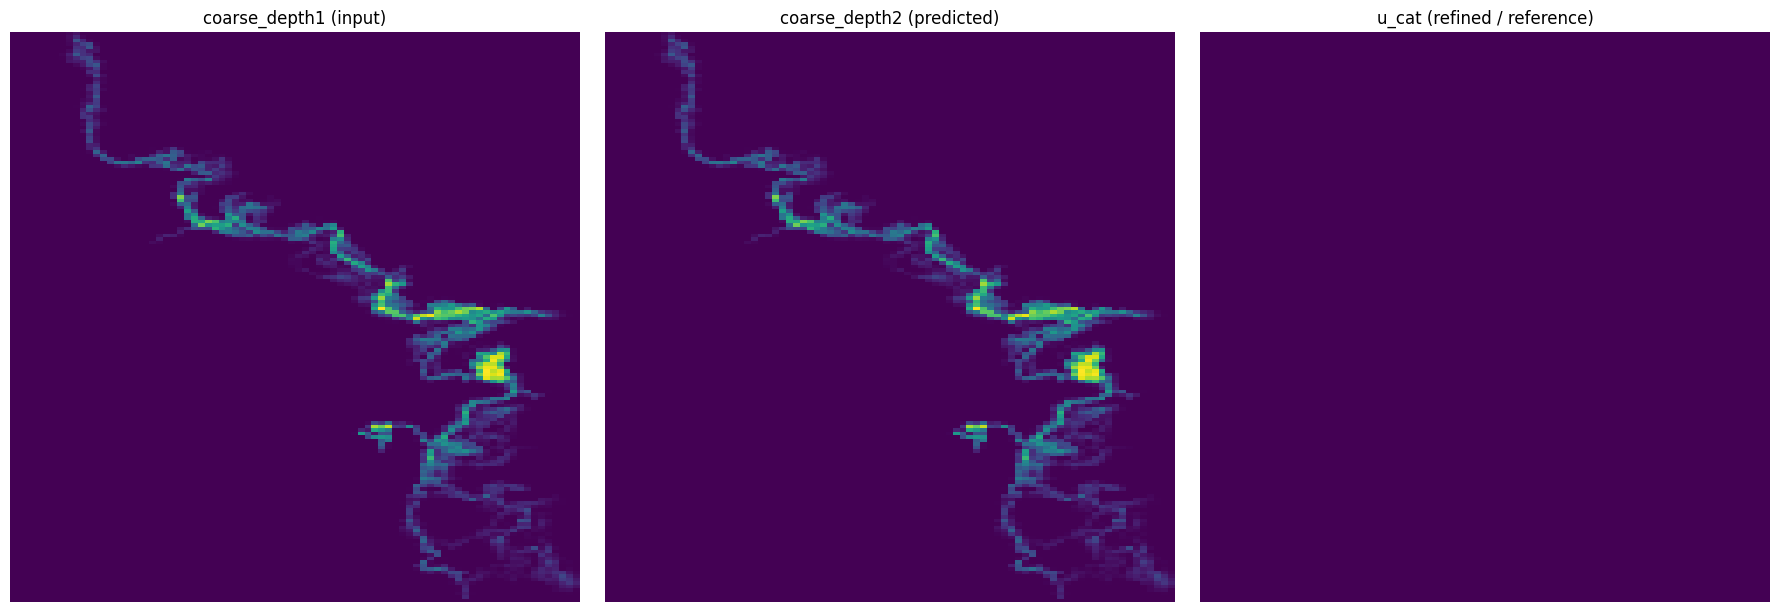

In [22]:
import matplotlib.pyplot as plt

# Extract the specific time slice (assuming tensors on GPU, move to CPU and convert to numpy)
img1 = coarse_depth1[3, :, :, 20].cpu().numpy()   # coarse input
img2 = coarse_depth2[3, :, :, 20].cpu().numpy()   # coarse prediction or intermediate
# img3 = u_cat[3, :, :, 20].cpu().numpy()           # refined / reference
img3 = (coarse_depth1[3, :, :, 20].cpu().numpy() - coarse_depth2[3, :, :, 20].cpu().numpy())
# Define the same physical extent for all three subplots
# Adjust these values to match your actual domain (e.g., x from 0 to Lx, y from 0 to Ly)
extent = [0, 1, 0, 1]  # [x_min, x_max, y_min, y_max]

# Create figure with 3 side-by-side subplots
plt.figure(figsize=(18, 6))  # wider for clear pixel visibility

# ────────────────────── Coarse Input ──────────────────────
plt.subplot(1, 3, 1)
plt.imshow(img1, 
           cmap='viridis', 
           interpolation='none',      # crucial: no smoothing → pixel-perfect
           extent=extent, 
           origin='lower')            # usually needed for physical coordinates
plt.title('coarse_depth1 (input)')
plt.axis('off')

# ────────────────────── Coarse Prediction ──────────────────────
plt.subplot(1, 3, 2)
plt.imshow(img2, 
           cmap='viridis', 
           interpolation='none', 
           extent=extent, 
           origin='lower')
plt.title('coarse_depth2 (predicted)')
plt.axis('off')

# ────────────────────── Refined / Reference ──────────────────────
plt.subplot(1, 3, 3)
plt.imshow(img3, 
           cmap='viridis', 
           interpolation='none', 
           extent=extent, 
           origin='lower')
plt.title('u_cat (refined / reference)')
plt.axis('off')

# Ensure consistent aspect ratio across all plots (critical for same extent)
for ax in plt.gcf().axes[:-3]:  # exclude colorbar axes
    ax.set_aspect('equal')     # physical x and y units have same scaling

plt.tight_layout()
plt.show()

In [ ]:
import torch
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import HTML
from datetime import datetime, timedelta
import numpy as np

# ==========================================
# 0) Get 4 samples (unsqueeze(0) then cat)
# ==========================================
a_batch, u_batch = next(iter(eval_loader))  # u_batch: [B, nx, ny, nt] (assumed)
idx = torch.randperm(u_batch.size(0))[:4]   # choose 4 random indices from this batch

u_list = [u_batch[i].unsqueeze(0) for i in idx]   # each: [1, nx, ny, nt]
u_4 = torch.cat(u_list, dim=0)                    # [4, nx, ny, nt]

# If you also want the matching inputs:
# a_list = [a_batch[i].unsqueeze(0) for i in idx]
# a_4 = torch.cat(a_list, dim=0)

# For titles (these are indices within THIS BATCH)
batch_indices = idx.tolist()

# ==========================================
# 1) Configuration
# ==========================================
start_date = datetime(2016, 10, 5, 12, 0, 0)
time_step_seconds = 3600

depth_samples = u_4.cpu().numpy()               # [4, nx, ny, nt]
num_frames = depth_samples.shape[-1]
time_dates = [start_date + timedelta(seconds=i * time_step_seconds) for i in range(num_frames)]

vmax_global = depth_samples.max() * 0.7

# ==========================================
# 2) Initialize Figure & 2x2 Subplots
# ==========================================
fig, axes = plt.subplots(2, 2, figsize=(10, 7), sharex=True, sharey=True)
axes = axes.flatten()
ims = []

extent = [0, 1, 0, 1]  # keep your normalized extent

for i in range(4):
    ax = axes[i]

    z_init = depth_samples[i, :, :, 0]
    im = ax.imshow(
        z_init.T,
        extent=extent,
        origin='lower',
        cmap='terrain',
        vmin=0,
        vmax=vmax_global
    )

    ax.set_title(f"Batch sample idx {batch_indices[i]}", fontsize=12)
    ax.grid(True, linestyle='--', alpha=0.3)
    ims.append(im)

# Single colorbar
cbar_ax = fig.add_axes([0.15, 0.05, 0.7, 0.02])
fig.colorbar(ims[0], cax=cbar_ax, label='Water Depth (m)', orientation='horizontal')

plt.subplots_adjust(bottom=0.15, hspace=0.2, wspace=0.1)

# ==========================================
# 3) Update Function
# ==========================================
def update(frame_idx):
    current_dt = time_dates[frame_idx]
    fig.suptitle(
        f"Hurricane Matthew\nTime: {current_dt.strftime('%Y-%m-%d %H:%M')}",
        fontsize=16,
        fontweight='bold'
    )

    for i, im in enumerate(ims):
        z_frame = depth_samples[i, :, :, frame_idx]
        im.set_data(z_frame.T)

    return ims

# ==========================================
# 4) Animation
# ==========================================
ani = animation.FuncAnimation(fig, update, frames=range(num_frames), interval=150, blit=False)
plt.close(fig)
HTML(ani.to_jshtml())


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import HTML
from datetime import datetime, timedelta
import numpy as np

# ==========================================
# 0. Configuration
# ==========================================
batch_indices = [0, 10, 20, 30]  # The 4 samples you want to compare
start_date = datetime(2016, 10, 5, 12, 0, 0)
time_step_seconds = 3600 

# Extract data for the 4 batches
# Shape: [4, nx, ny, nt]
depth_samples = depth_tensor[batch_indices].cpu().numpy()
num_frames = depth_samples.shape[-1]
time_dates = [start_date + timedelta(seconds=i * time_step_seconds) for i in range(num_frames)]

# Global VMAX for consistent scaling across all panels
vmax_global = depth_samples.max() * 0.7

# ==========================================
# 1. Initialize Figure & 2x2 Subplots
# ==========================================
fig, axes = plt.subplots(2, 2, figsize=(10, 7), sharex=True, sharey=True)
axes = axes.flatten() # Flatten 2D array of axes to 1D for easy looping
ims = []

for i, b_idx in enumerate(batch_indices):
    ax = axes[i]
    
    # Get spatial extent for this specific batch
    extent = [
        x_tensor.min().item(), x_tensor.max().item(), 
        y_tensor.min().item(), y_tensor.max().item()
    ]
    
    # Initial frame for this subplot
    z_init = depth_samples[i, :, :, 0]
    
    # Plot using 'Blues' for HEC-RAS style
    im = ax.imshow(z_init.T, extent=extent, origin='lower', cmap='terrain', 
                   vmin=0, vmax=vmax_global)
    
    ax.set_title(f"Scenario {b_idx}", fontsize=12)
    ax.grid(True, linestyle='--', alpha=0.3)
    ims.append(im)

# Single colorbar for the whole figure
cbar_ax = fig.add_axes([0.15, 0.05, 0.7, 0.02]) # [left, bottom, width, height]
fig.colorbar(ims[0], cax=cbar_ax, label='Water Depth (m)', orientation='horizontal')

plt.subplots_adjust(bottom=0.15, hspace=0.2, wspace=0.1)

# ==========================================
# 2. Update Function
# ==========================================

def update(frame_idx):
    current_dt = time_dates[frame_idx]
    fig.suptitle(f"Hurricane Matthew\nTime: {current_dt.strftime('%Y-%m-%d %H:%M')}", 
                 fontsize=16, fontweight='bold')
    
    # Update each panel
    for i, im in enumerate(ims):
        z_frame = depth_samples[i, :, :, frame_idx]
        im.set_data(z_frame.T)
    
    return ims

# ==========================================
# 3. Execution
# ==========================================
ani = animation.FuncAnimation(fig, update, frames=range(num_frames), 
                              interval=150, blit=False)

plt.close(fig) 
HTML(ani.to_jshtml())

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import HTML
from datetime import datetime, timedelta
import numpy as np

# ==========================================
# 0. Configuration & Data Prep
# ==========================================
batch_indices = [0, 10, 20, 30] 
start_date = datetime(2016, 10, 5, 12, 0, 0)

# Extract samples: [4, nx, ny, nt]
depth_samples = depth_tensor[batch_indices].cpu().numpy()
q_samples = q_tensor[batch_indices].cpu().numpy()
num_frames = depth_samples.shape[-1]

# Use the actual time tensor for accurate dates
time_seconds = t_tensor.cpu().numpy()
time_dates = [start_date + timedelta(seconds=float(s)) for s in time_seconds]

# Static spatial extent
extent = [
    x_tensor.min().item(), x_tensor.max().item(), 
    y_tensor.min().item(), y_tensor.max().item()
]

# Consistent scaling
vmax_depth = depth_samples.max() * 0.7
vmax_q = q_samples.max() * 0.8  # Adjust based on your hydrograph peaks

# ==========================================
# 1. Initialize Figure & 4x2 Subplots
# ==========================================
# 4 columns (scenarios), 2 rows (Top: Depth, Bottom: Q)
fig, axes = plt.subplots(2, 4, figsize=(18, 8), sharex=True, sharey=True)
depth_ims = []
q_ims = []

for i, b_idx in enumerate(batch_indices):
    # --- Top Row: Depth ---
    ax_d = axes[0, i]
    z_d_init = depth_samples[i, ..., 0]
    im_d = ax_d.imshow(z_d_init.T, extent=extent, origin='lower', 
                       cmap='terrain', vmin=0, vmax=vmax_depth)
    ax_d.set_title(f"Scenario {b_idx}\nWater Depth (m)", fontsize=11)
    depth_ims.append(im_d)
    
    # --- Bottom Row: Discharge (Q) ---
    ax_q = axes[1, i]
    z_q_init = q_samples[i, ..., 0]
    im_q = ax_q.imshow(z_q_init.T, extent=extent, origin='lower', 
                       cmap='jet', vmin=5, vmax=vmax_q)
    ax_q.set_title(f"Discharge Q ($m^3/s$)", fontsize=11)
    q_ims.append(im_q)
    
    # Common formatting
    for ax in [ax_d, ax_q]:
        ax.grid(True, linestyle='--', alpha=0.3)

# Individual colorbars for Depth and Q
cbar_ax_d = fig.add_axes([0.92, 0.55, 0.015, 0.3]) # [left, bottom, width, height]
fig.colorbar(depth_ims[0], cax=cbar_ax_d, label='Depth (m)')

cbar_ax_q = fig.add_axes([0.92, 0.15, 0.015, 0.3])
fig.colorbar(q_ims[0], cax=cbar_ax_q, label='Discharge $Q$')

plt.subplots_adjust(left=0.05, right=0.9, bottom=0.1, top=0.85, hspace=0.3, wspace=0.1)

# ==========================================
# 2. Update Function
# ==========================================
def update(frame_idx):
    current_dt = time_dates[frame_idx]
    fig.suptitle(f"Hurricane Matthew - Multi-Scenario Input/Output\nTime: {current_dt.strftime('%Y-%m-%d %H:%M')}", 
                 fontsize=16, fontweight='bold')
    
    for i in range(len(batch_indices)):
        # Update Depth
        depth_ims[i].set_data(depth_samples[i, ..., frame_idx].T)
        # Update Discharge
        q_ims[i].set_data(q_samples[i, ..., frame_idx].T)
    
    return depth_ims + q_ims

# ==========================================
# 3. Execution
# ==========================================
ani = animation.FuncAnimation(fig, update, frames=range(num_frames), 
                              interval=200, blit=False)

plt.close(fig) 
HTML(ani.to_jshtml())

In [ ]:
import matplotlib.pyplot as plt

# 1. Extract the specific timestep (index 30) for a specific scenario (e.g., index 0)
# DATA['discharge'] shape: [nbatch, nx, ny, nt]
scenario_idx = 0 
timestep_idx = 30
z = q_tensor[scenario_idx, ..., timestep_idx].cpu().numpy()

# 2. Define the geographic extent
# x_tensor and y_tensor are now [nx, ny] (no batch dimension)
extent = [
    x_tensor.min().item(), 
    x_tensor.max().item(), 
    y_tensor.min().item(), 
    y_tensor.max().item()
]

# 3. Create the Plot
fig, ax = plt.subplots(figsize=(10, 9))

# z.T: Transposes [nx, ny] to [ny, nx] so rows=Y and cols=X for imshow
# origin='lower': Maps the first row of data to the bottom of the plot
# cmap='Reds' for discharge intensity
im = ax.imshow(z.T, extent=extent, origin='lower', cmap='jet', vmin=0)

# 4. Formatting and Labels
fig.colorbar(im, ax=ax, label='Discharge $Q$ (m$^3$/s)', orientation='horizontal', pad=0.1)

# Display the specific simulation time from t_tensor
# t_tensor is [nt]
current_time = t_tensor[timestep_idx].item()
ax.set_title(f'Scenario {scenario_idx} - Discharge $Q$ (Step {timestep_idx})\nTime: {current_time:.1f} seconds')
ax.set_xlabel('UTM Easting (m)')
ax.set_ylabel('UTM Northing (m)')
ax.grid(True, linestyle='--', alpha=0.3)

plt.show()